In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# After running this, Colab will ask you to authorize access.

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os

data_path = "/content/drive/MyDrive/KolamDesign/dataset"

for root, dirs, files in os.walk(data_path):
    level = root.replace(data_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

step 2 import files normalize images


=== Augmenting images from class: freehandkolam ===
Found 5 images belonging to 1 classes.


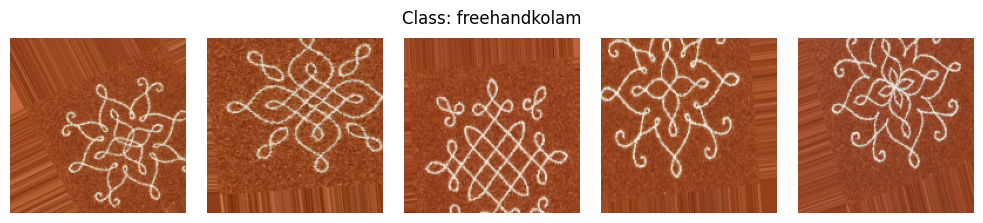


=== Augmenting images from class: Pullikolam ===
Found 5 images belonging to 1 classes.


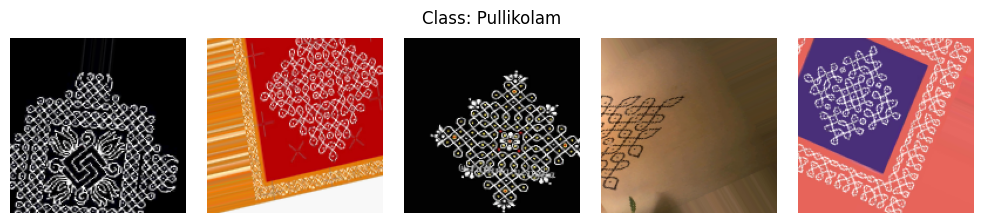


=== Augmenting images from class: Padikolam ===
Found 5 images belonging to 1 classes.


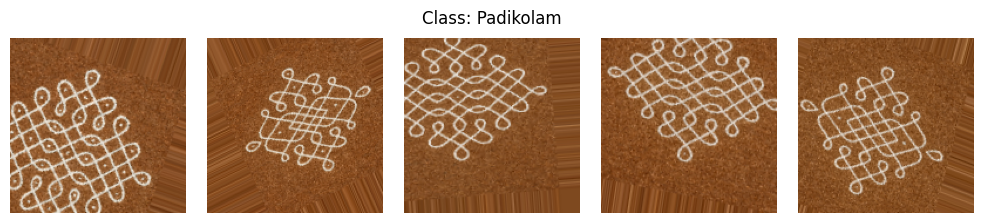


=== Augmenting images from class: sukkikolam ===
Found 5 images belonging to 1 classes.


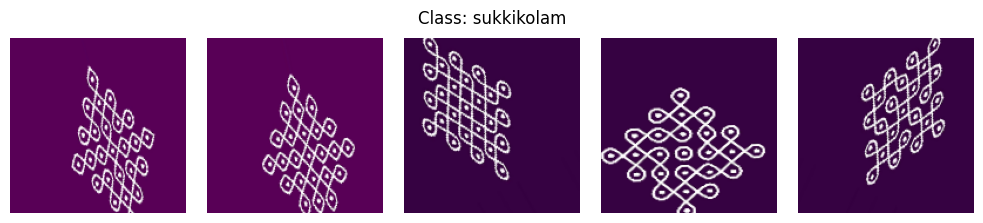


=== Augmenting images from class: Kambikolam ===
Found 5 images belonging to 1 classes.


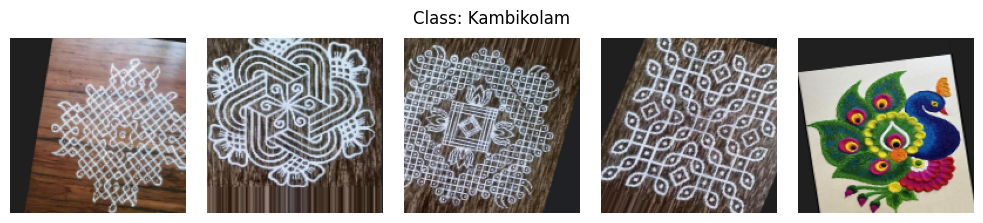

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

# Path to your dataset (with 5 class folders inside)
data_dir = "/content/drive/MyDrive/KolamDesign/KolamDesign/dataset/train/"

# Define augmentations
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Loop through each class folder separately
for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)
    if not os.path.isdir(cls_path):
        continue

    print(f"\n=== Augmenting images from class: {cls} ===")

    # Create a generator for this specific class folder
    generator = datagen.flow_from_directory(
        data_dir,                    # parent folder
        classes=[cls],               # only this class
        target_size=(150, 150),
        batch_size=25,               # you have 25 originals in total, adjust if fewer per class
        class_mode=None,
        shuffle=False
    )

    # Take one batch of augmented images
    augmented_images = next(generator)

    # Plot them (up to 25 per class)
    plt.figure(figsize=(10,10))
    for i in range(min(25, augmented_images.shape[0])):
        plt.subplot(5,5,i+1)
        plt.imshow(augmented_images[i].astype("uint8"))
        plt.axis("off")
    plt.suptitle(f"Class: {cls}")
    plt.tight_layout()
    plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os

# Original dataset (5 class folders)
data_dir = "/content/drive/MyDrive/KolamDesign/KolamDesign/dataset/train/"

# Where to save augmented images
save_dir = "/content/drive/MyDrive/KolamDesign/KolamDesign/augmented/"
os.makedirs(save_dir, exist_ok=True)

# Define augmentations
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Number of augmented images per original
augment_per_image = 120   # change as needed
target_size = (150, 150) # or (224,224) if using transfer learning models

# Loop through each class folder
for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)
    if not os.path.isdir(cls_path):
        continue

    print(f"\n=== Augmenting images from class: {cls} ===")

    # Create save path per class
    save_cls_dir = os.path.join(save_dir, cls)
    os.makedirs(save_cls_dir, exist_ok=True)

    # Go through each image in the class
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img = load_img(img_path, target_size=target_size)
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        # Generate and save augmented images
        i = 0
        for batch in datagen.flow(x, batch_size=1,
                                  save_to_dir=save_cls_dir,
                                  save_prefix=f"aug_{os.path.splitext(fname)[0]}",
                                  save_format="jpg"):
            i += 1
            if i >= augment_per_image:
                break

    print(f"Saved augmented images in {save_cls_dir}")

print("\n✅ Augmentation complete. Check:", save_dir)



=== Augmenting images from class: freehandkolam ===
Saved augmented images in /content/drive/MyDrive/KolamDesign/KolamDesign/augmented/freehandkolam

=== Augmenting images from class: Pullikolam ===
Saved augmented images in /content/drive/MyDrive/KolamDesign/KolamDesign/augmented/Pullikolam

=== Augmenting images from class: Padikolam ===
Saved augmented images in /content/drive/MyDrive/KolamDesign/KolamDesign/augmented/Padikolam

=== Augmenting images from class: sukkikolam ===
Saved augmented images in /content/drive/MyDrive/KolamDesign/KolamDesign/augmented/sukkikolam

=== Augmenting images from class: Kambikolam ===
Saved augmented images in /content/drive/MyDrive/KolamDesign/KolamDesign/augmented/Kambikolam

✅ Augmentation complete. Check: /content/drive/MyDrive/KolamDesign/KolamDesign/augmented/


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import os, shutil
from sklearn.model_selection import train_test_split

# Paths
data_dir = "/content/drive/MyDrive/KolamDesign/KolamDesign/dataset/train/"   # original dataset
augmented_dir = "/content/drive/MyDrive/KolamDesign/KolamDesign/augmented/" # augmented dataset
prepared_dir = "/content/drive/MyDrive/KolamDesign/KolamDesign/prepared/"   # final split dataset

os.makedirs(augmented_dir, exist_ok=True)
os.makedirs(prepared_dir, exist_ok=True)

# Define augmentations
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

augment_per_image = 10       # how many augmented versions per original
target_size = (150, 150)     # better for transfer learning

# === Step 1: Augment into per-class folders ===
for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)
    if not os.path.isdir(cls_path):
        continue

    print(f"\n=== Augmenting images from class: {cls} ===")
    save_cls_dir = os.path.join(augmented_dir, cls)
    os.makedirs(save_cls_dir, exist_ok=True)

    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img = load_img(img_path, target_size=target_size)
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        i = 0
        for batch in datagen.flow(x, batch_size=1,
                                  save_to_dir=save_cls_dir,
                                  save_prefix=f"aug_{os.path.splitext(fname)[0]}",
                                  save_format="jpg"):
            i += 1
            if i >= augment_per_image:
                break

    print(f"Saved augmented images in {save_cls_dir}")

print("\n✅ Augmentation complete!")

# === Step 2: Split into train/val/test ===
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
random_state = 42

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(prepared_dir, split), exist_ok=True)

for cls in os.listdir(augmented_dir):
    cls_path = os.path.join(augmented_dir, cls)
    if not os.path.isdir(cls_path):
        continue

    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".jpeg",".png"))]

    # split per-class
    train_files, temp = train_test_split(imgs, train_size=train_ratio, random_state=random_state)
    relative_val = val_ratio / (val_ratio + test_ratio)
    val_files, test_files = train_test_split(temp, train_size=relative_val, random_state=random_state)

    for split_name, files in zip(["train","val","test"], [train_files, val_files, test_files]):
        split_cls_dir = os.path.join(prepared_dir, split_name, cls)
        os.makedirs(split_cls_dir, exist_ok=True)
        for f in files:
            shutil.copy(os.path.join(cls_path, f), os.path.join(split_cls_dir, f))

print("\n✅ Dataset split into train/val/test at:", prepared_dir)



=== Augmenting images from class: freehandkolam ===
Saved augmented images in /content/drive/MyDrive/KolamDesign/KolamDesign/augmented/freehandkolam

=== Augmenting images from class: Pullikolam ===
Saved augmented images in /content/drive/MyDrive/KolamDesign/KolamDesign/augmented/Pullikolam

=== Augmenting images from class: Padikolam ===
Saved augmented images in /content/drive/MyDrive/KolamDesign/KolamDesign/augmented/Padikolam

=== Augmenting images from class: sukkikolam ===
Saved augmented images in /content/drive/MyDrive/KolamDesign/KolamDesign/augmented/sukkikolam

=== Augmenting images from class: Kambikolam ===
Saved augmented images in /content/drive/MyDrive/KolamDesign/KolamDesign/augmented/Kambikolam

✅ Augmentation complete!

✅ Dataset split into train/val/test at: /content/drive/MyDrive/KolamDesign/KolamDesign/prepared/


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import os

# === Paths ===
prepared_dir = "/content/drive/MyDrive/KolamDesign/KolamDesign/prepared/"
train_dir = os.path.join(prepared_dir, "train")
val_dir = os.path.join(prepared_dir, "val")
test_dir = os.path.join(prepared_dir, "test")

# === Parameters ===
img_size = (150, 150)   # smaller size = faster training
batch_size = 16         # reduce memory load
epochs = 10             # start small, can increase later

# === Data Generators ===
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical"
)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical", shuffle=False
)

# === Transfer Learning Model (MobileNetV2) ===
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(150,150,3))
base_model.trainable = False  # freeze pretrained layers

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(train_gen.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# === Compile ===
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# === Train ===
history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen
)

# === Fine-tune (optional, unfreeze last 20 layers) ===
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),  # smaller LR
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history_finetune = model.fit(
    train_gen,
    epochs=5,
    validation_data=val_gen
)

# === Evaluate on Test Set ===
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc:.2f}")

# === Save Model ===
model.save("/content/drive/MyDrive/KolamDesign/KolamDesign/kolam_mobilenetv2.h5")
print("Model saved successfully!")


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# Load your saved model
model = tf.keras.models.load_model("/content/drive/MyDrive/KolamDesign/KolamDesign/kolam_mobilenetv2.h5")

# Path to a new test image (give the full path here)
img_path = "/content/Freehand1.png"
# Preprocess the image
img = image.load_img(img_path, target_size=(150, 150))  # same size as training
img_array = image.img_to_array(img) / 255.0            # normalize
img_array = np.expand_dims(img_array, axis=0)          # add batch dimension

# Predict
pred = model.predict(img_array)
class_index = np.argmax(pred)   # predicted class index

# Map index back to class label
# You'll need to get the class labels from your training generator
# For example: class_labels = list(train_gen.class_indices.keys())
# Since train_gen is not available here, we'll just print the index and prediction vector
class_labels = None # Placeholder

if class_labels:
    print("✅ Predicted class:", class_labels[class_index])
else:
    print("✅ Predicted class index:", class_index)
    print("Prediction vector:", pred)

In [ ]:
import json

# Get class labels mapping
class_labels = list(train_gen.class_indices.keys())
print("Class labels:", class_labels)

# Save them to a JSON file
with open("/content/drive/MyDrive/KolamDesign/KolamDesign/class_labels.json", "w") as f:
    json.dump(class_labels, f)


In [ ]:
import json
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# Load the model
model = tf.keras.models.load_model("/content/drive/MyDrive/KolamDesign/KolamDesign/kolam_mobilenetv2.h5")

# Load the class labels
with open("/content/drive/MyDrive/KolamDesign/KolamDesign/class_labels.json", "r") as f:
    class_labels = json.load(f)

# Path to new test image
img_path = "/content/ChatGPT Image Sep 20, 2025, 12_47_28 AM.png"

# Preprocess the image
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
class_index = np.argmax(pred)

print("✅ Predicted class:", class_labels[class_index])
print("Prediction vector:", pred)


In [ ]:
# Print the class mapping created by ImageDataGenerator
print("Class indices mapping (folder → index):")
print(train_gen.class_indices)

# Also save the labels in correct order
class_labels = list(train_gen.class_indices.keys())
print("Ordered class labels:", class_labels)

# (Optional) Save to JSON for later use
import json
with open("/content/drive/MyDrive/KolamDesign/KolamDesign/class_labels.json", "w") as f:
    json.dump(class_labels, f)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16  # you can also try ResNet50, MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import os

# Paths
prepared_dir = "/content/drive/MyDrive/KolamDesign/KolamDesign/prepared/"
train_dir = os.path.join(prepared_dir, "train")
val_dir = os.path.join(prepared_dir, "val")
test_dir = os.path.join(prepared_dir, "test")

# Parameters
img_size = (224, 224)   # standard size for pretrained models
batch_size = 32
epochs = 15   # increase later if accuracy is low

# === Data Generators ===
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical"
)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical", shuffle=False
)

# === Transfer Learning Model (VGG16) ===
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
for layer in base_model.layers:
    layer.trainable = False   # freeze pretrained layers

x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(train_gen.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# === Train ===
history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen
)

# === Evaluate on Test Set ===
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc:.2f}")

# === Save Model ===
model.save("/content/drive/MyDrive/KolamDesign/KolamDesign/kolam_model.h5")
print("Model saved successfully!")


In [ ]:
import os
import hashlib

# Paths to your train and validation folders
train_dir = "/content/drive/MyDrive/KolamDesign/dataset/train"
val_dir   = "/content/drive/MyDrive/KolamDesign/dataset/val"

def get_file_hash(file_path):
    """Return MD5 hash of a file (unique fingerprint)."""
    hash_md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

def collect_hashes(folder):
    file_hashes = {}
    for root, _, files in os.walk(folder):
        for file in files:
            file_path = os.path.join(root, file)
            file_hashes[file_path] = get_file_hash(file_path)
    return file_hashes

# Get hashes for train and val sets
train_hashes = collect_hashes(train_dir)
val_hashes   = collect_hashes(val_dir)

# Find duplicates
duplicates = []
for val_file, val_hash in val_hashes.items():
    for train_file, train_hash in train_hashes.items():
        if val_hash == train_hash:
            duplicates.append((train_file, val_file))

# Print results
if duplicates:
    print("⚠️ Found duplicates between training and validation sets:")
    for t, v in duplicates:
        print(f"Train: {t}  <-->  Val: {v}")
else:
    print("✅ No duplicate images found between training and validation sets.")
